# Interpolation
Interpolation is a mathematical technique to build a function from a sample of data points to return a value for points in the same region where there is a lack of observations. The purpose is different from that in least-squares optimization where the task is to fit a function among several observations. Moreover, the interpolating function crosses all the samples. The values of the function should be taken only within the sample region. When the interpolating function is used to estimate values outside of the sample region the task is that of extrapolation. The accuracy of this latter task is lower and might be totally inaccurate. Extrapolation is not treated in this chapter. 
The examples in this notebook follow those from chapter 7 of the book by Johansson [*Numerical Python, 3rd Edition*](https://github.com/jrjohansson/numerical-python-book-code/blob/master/ch07-code-listing.ipynb). 

In [2]:
import numpy as np
from numpy import polynomial as P
import sympy
import scipy
from scipy import linalg as la
from scipy import interpolate
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D
print('NumPy version: {}'.format(np.__version__))
print('SymPy version: {}'.format(sympy.__version__))
print('SciPy version: {}'.format(scipy.__version__))
print('Matplotlib version: {}'.format(mpl.__version__))

NumPy version: 1.26.4
SymPy version: 1.14.0
SciPy version: 1.17.1
Matplotlib version: 3.8.4


Given a sample of data n points $(x_i, y_i), i=1,2,...n$, the interpolation problem can be stated as finding a function $y = f(x)$ so that $y_i = f(x_i)$. One approach is to define the interpolating function as a linear combination of m polynomial terms, also known as basis functions $\phi_j(x) \propto x^j$, so that
$$f(x) = \sum_{j=0}^m c_j \phi_j(x)$$
Evaluating the interpolating function for n data points using m terms results in a linear system of n equation in m variables $c_j$. 
$$y_i = \sum_{j=0}^m c_j \phi_j(x_i), \ (i=1,2,...,n)$$
Common sets of polynomials with the properties of being [orthogonal](https://en.wikipedia.org/wiki/Orthogonal_polynomials) are the [Legendre](https://en.wikipedia.org/wiki/Legendre_polynomials), [Chebyshev](https://en.wikipedia.org/wiki/Chebyshev_polynomials), and [Hermite](https://en.wikipedia.org/wiki/Hermite_polynomials) polynomials. We can write the linear system as
$$\hat{\Phi}(x) c = y$$
where $\hat{\Phi}(x)$ is a matrix of $\phi_{ij}$ elements called Vandermonde matrix. To solve the problem we have to invert the matrix $\Phi(x)$ so that 
$$c = \hat{\Phi}^{-1}(x)y$$
The elements of the Vandermonde matrix $\Phi(x)$ depend on the chosen basis functions. The [NumPy Polynomial](https://numpy.org/doc/stable/reference/routines.polynomials.html) package provides the classes to build polynomials and to build the interpolating function of an array of data points $(x_i, y_i)$. With this package we can build polynomials by simply setting the coefficients. The default basis are the powers of the variable $x^j$

In [3]:
p1 = P.Polynomial([1,2,3])
p1

Polynomial([1., 2., 3.], domain=[-1,  1], window=[-1,  1], symbol='x')

In [9]:
p1(2.0)

17.0

We can use a different set of basis function, e.g. Chebyshev's

In [10]:
c1 = P.Chebyshev([1, 2, 3])
c1

Chebyshev([1., 2., 3.], domain=[-1,  1], window=[-1,  1], symbol='x')

In [11]:
c1(2.0)

26.0

In [12]:
x = np.array([1, 2, 3, 4])
y = np.array([1, 3, 5, 4])

In [13]:
deg = len(x) - 1

In [15]:
A = P.polynomial.polyvander(x, deg)
c = la.solve(A, y)
c

array([ 2. , -3.5,  3. , -0.5])

In [16]:
f1 = P.Polynomial(c)
f1

Polynomial([ 2. , -3.5,  3. , -0.5], domain=[-1,  1], window=[-1,  1], symbol='x')

In [17]:
f1(x)

array([1., 3., 5., 4.])

In [21]:
f1(2.5)

4.1875

In [19]:
C = P.chebyshev.chebvander(x, deg)
c = la.solve(C, y)
c

array([ 3.5  , -3.875,  1.5  , -0.125])

In [20]:
f2 = P.Chebyshev(c)
f2

Chebyshev([ 3.5  , -3.875,  1.5  , -0.125], domain=[-1,  1], window=[-1,  1], symbol='x')

In [22]:
f2(2.5)

4.187500000000001

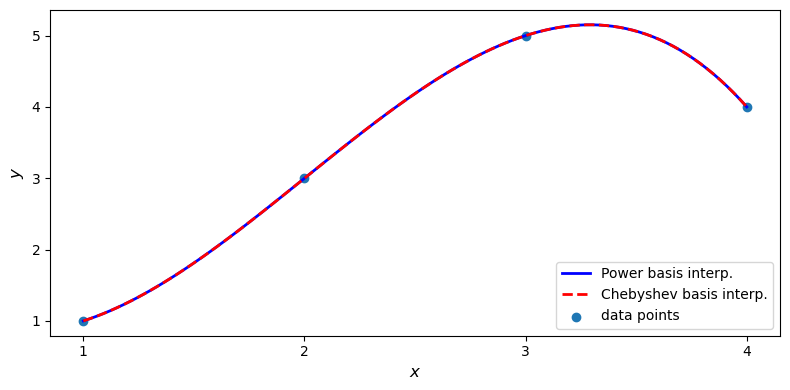

In [24]:
xx = np.linspace(x.min(), x.max(), 100)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

ax.plot(xx, f1(xx), 'b', lw=2, label='Power basis interp.')
ax.plot(xx, f2(xx), 'r--', lw=2, label='Chebyshev basis interp.')
ax.scatter(x, y, label='data points')

ax.legend(loc=4)
ax.set_xticks(x)
ax.set_ylabel(r"$y$", fontsize=12)
ax.set_xlabel(r"$x$", fontsize=12)

fig.tight_layout()